# Analisis Lanjutan: Risiko, Korelasi, dan Forecasting Saham Rantai Pasok Pangan IDX

Notebook ini melengkapi analisis di dashboard Power BI dan query SQL dengan tiga hal yang belum tercakup di sana:

1. **Korelasi antar saham** — apakah saham-saham ini bergerak bersamaan atau independen
2. **Metrik risiko** (Sharpe Ratio & Maximum Drawdown) — mengukur return relatif terhadap risiko yang diambil
3. **Uji statistik** — apakah perbedaan return antar periode benar-benar signifikan, atau cuma kebetulan
4. **Forecasting sederhana** — model regresi linear untuk memprediksi return harian dari data historisnya sendiri

> Catatan: seluruh analisis di notebook ini untuk tujuan pembelajaran/portofolio, bukan rekomendasi investasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

## 1. Muat Data

In [2]:
harga = pd.read_csv("harga_saham_pangan.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("return_harian_pangan.csv", index_col=0, parse_dates=True)
ringkasan = pd.read_csv("ringkasan_sektor_pangan.csv")

print(f"Data harga: {harga.shape[0]} hari, {harga.shape[1]} instrumen")
print(f"Periode: {harga.index.min().date()} s/d {harga.index.max().date()}")
harga.tail()

Data harga: 842 hari, 7 instrumen
Periode: 2023-01-02 s/d 2026-07-20


,AALI.JK,BISI.JK,CPIN.JK,JPFA.JK,ICBP.JK,INDF.JK,^JKSE
Date,,,,,,,
2026-07-14,6300.0,630.0,3100.0,2020.0,6650.0,6775.0,6039.520996
2026-07-15,6300.0,625.0,3070.0,2030.0,6600.0,6750.0,6041.972168
2026-07-16,6425.0,640.0,3110.0,2030.0,6700.0,6750.0,6108.208984
2026-07-17,6450.0,645.0,3120.0,2070.0,6850.0,6700.0,6175.535156
2026-07-20,6525.0,660.0,3110.0,2080.0,6900.0,6800.0,6175.535156


## 2. Korelasi Antar Saham

Korelasi return harian menunjukkan apakah dua saham cenderung bergerak searah (korelasi positif, mendekati +1),
berlawanan arah (korelasi negatif, mendekati -1), atau tidak berhubungan (mendekati 0).

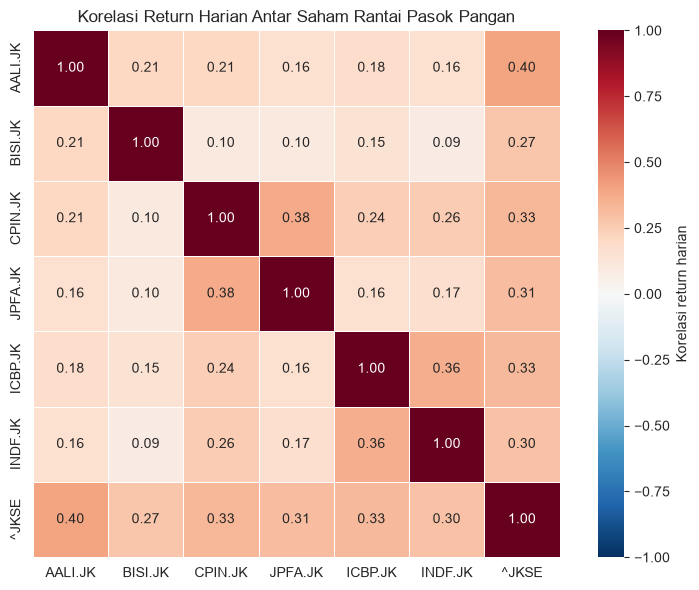

,AALI.JK,BISI.JK,CPIN.JK,JPFA.JK,ICBP.JK,INDF.JK,^JKSE
AALI.JK,1.00,0.21,0.21,0.16,0.18,0.16,0.40
BISI.JK,0.21,1.00,0.10,0.10,0.15,0.09,0.27
CPIN.JK,0.21,0.10,1.00,0.38,0.24,0.26,0.33
JPFA.JK,0.16,0.10,0.38,1.00,0.16,0.17,0.31
ICBP.JK,0.18,0.15,0.24,0.16,1.00,0.36,0.33
INDF.JK,0.16,0.09,0.26,0.17,0.36,1.00,0.30
^JKSE,0.40,0.27,0.33,0.31,0.33,0.30,1.00


In [3]:
korelasi = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Korelasi return harian"})
plt.title("Korelasi Return Harian Antar Saham Rantai Pasok Pangan")
plt.tight_layout()
plt.show()

korelasi.round(2)

> **Catatan interpretasi:** Korelasi antar saham pangan tergolong lemah-sedang (0,10–0,40), menunjukkan diversifikasi yang cukup baik — pergerakan satu saham tidak serta-merta diikuti saham lain di sektor yang sama. Korelasi tertinggi justru antara CPIN.JK dan JPFA.JK (0,38), keduanya di tahap menengah (peternakan/pakan) — masuk akal karena sama-sama terekspos ke faktor seperti harga pakan ternak. Menariknya, korelasi tiap saham terhadap IHSG (0,27–0,40) justru lebih tinggi dibanding korelasi antar sesama saham pangan, menandakan pergerakan pasar secara umum tetap jadi faktor dominan dibanding hubungan sektoral yang sempit.

## 3. Sharpe Ratio (Return Disesuaikan Risiko)

Sharpe Ratio mengukur seberapa besar return yang didapat per unit risiko (volatilitas) yang diambil.
Semakin tinggi, semakin baik return yang didapat relatif terhadap risikonya.

Asumsi: risk-free rate = 0% (disederhanakan; bisa diganti suku bunga acuan BI untuk versi lebih presisi).

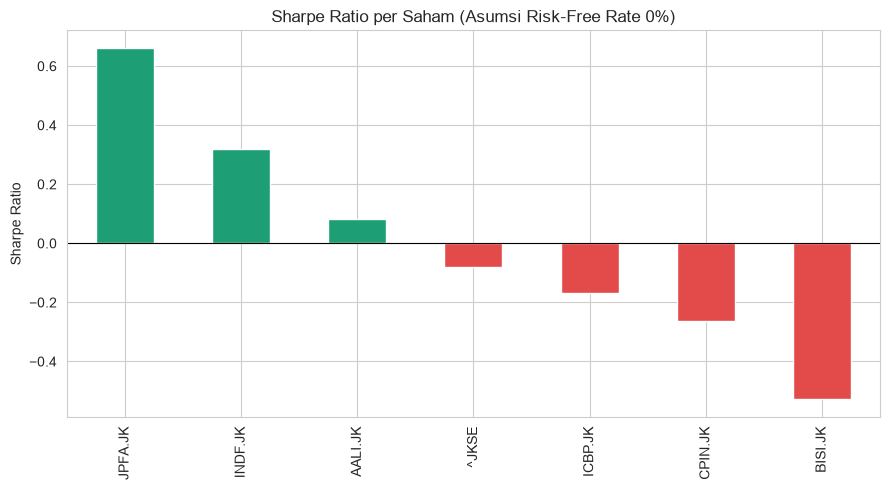

JPFA.JK    0.661
INDF.JK    0.318
AALI.JK    0.082
^JKSE     -0.080
ICBP.JK   -0.170
CPIN.JK   -0.264
BISI.JK   -0.529
Name: Sharpe Ratio (tahunan), dtype: float64

In [4]:
RISK_FREE_RATE_TAHUNAN = 0.0
HARI_TRADING_SETAHUN = 252

sharpe = {}
for t in harga.columns:
    r = returns[t].dropna()
    excess_return = r.mean() - (RISK_FREE_RATE_TAHUNAN / HARI_TRADING_SETAHUN)
    sharpe[t] = (excess_return / r.std()) * np.sqrt(HARI_TRADING_SETAHUN)

df_sharpe = pd.Series(sharpe, name="Sharpe Ratio (tahunan)").sort_values(ascending=False)

plt.figure(figsize=(9, 5))
warna = ["#1D9E75" if x > 0 else "#E24B4A" for x in df_sharpe]
df_sharpe.plot(kind="bar", color=warna)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Sharpe Ratio per Saham (Asumsi Risk-Free Rate 0%)")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

df_sharpe.round(3)

## 4. Maximum Drawdown (Risiko Penurunan Terbesar)

Maximum Drawdown mengukur penurunan terbesar dari titik puncak ke titik terendah berikutnya —
metrik risiko yang penting karena menunjukkan potensi kerugian maksimum yang pernah dialami investor
yang membeli di titik tertinggi.

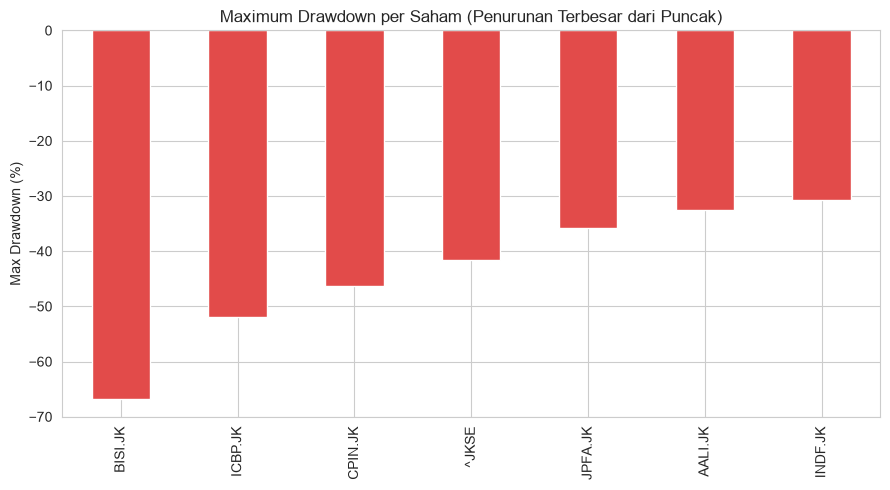

BISI.JK   -66.72
ICBP.JK   -52.00
CPIN.JK   -46.31
^JKSE     -41.52
JPFA.JK   -35.72
AALI.JK   -32.61
INDF.JK   -30.79
Name: Max Drawdown, dtype: float64

In [5]:
def hitung_max_drawdown(return_harian):
    kumulatif = (1 + return_harian.dropna()).cumprod()
    puncak_berjalan = kumulatif.cummax()
    drawdown = (kumulatif - puncak_berjalan) / puncak_berjalan
    return drawdown.min()

max_dd = pd.Series(
    {t: hitung_max_drawdown(returns[t]) for t in harga.columns}, name="Max Drawdown"
).sort_values()

plt.figure(figsize=(9, 5))
(max_dd * 100).plot(kind="bar", color="#E24B4A")
plt.title("Maximum Drawdown per Saham (Penurunan Terbesar dari Puncak)")
plt.ylabel("Max Drawdown (%)")
plt.tight_layout()
plt.show()

(max_dd * 100).round(2)

### 4b. Volatilitas Tahunan & Agregasi Risiko per Tahap Rantai Pasok

Volatilitas tahunan belum dihitung sebagai metrik tersendiri di bagian sebelumnya (hanya dipakai sebagai
komponen pembagi di rumus Sharpe Ratio). Di sini dihitung eksplisit: `std(return harian) * sqrt(252)`,
lalu dirata-rata per tahap rantai pasok — Hulu (AALI.JK, BISI.JK), Menengah (CPIN.JK, JPFA.JK),
Hilir (ICBP.JK, INDF.JK). ^JKSE dikecualikan dari agregasi karena berperan sebagai benchmark, bukan
bagian dari rantai pasok pangan.

In [6]:
HARI_TRADING_SETAHUN = 252

tahap_rantai_pasok = {
    "AALI.JK": "Hulu (Pertanian/Perkebunan)",
    "BISI.JK": "Hulu (Pertanian/Perkebunan)",
    "CPIN.JK": "Menengah (Peternakan/Pakan/Protein)",
    "JPFA.JK": "Menengah (Peternakan/Pakan/Protein)",
    "ICBP.JK": "Hilir (Pengolahan Pangan)",
    "INDF.JK": "Hilir (Pengolahan Pangan)",
}

volatilitas_tahunan = returns.std() * np.sqrt(HARI_TRADING_SETAHUN) * 100

df_risiko = pd.DataFrame({
    "Volatilitas Tahunan (%)": volatilitas_tahunan,
    "Max Drawdown (%)": max_dd * 100,
})
df_risiko["Tahap Rantai Pasok"] = df_risiko.index.map(tahap_rantai_pasok)

print("Volatilitas Tahunan & Max Drawdown per Ticker:")
print(df_risiko.round(2))

agregasi_tahap = (
    df_risiko.dropna(subset=["Tahap Rantai Pasok"])
    .groupby("Tahap Rantai Pasok")[["Volatilitas Tahunan (%)", "Max Drawdown (%)"]]
    .mean()
    .reindex([
        "Hulu (Pertanian/Perkebunan)",
        "Menengah (Peternakan/Pakan/Protein)",
        "Hilir (Pengolahan Pangan)",
    ])
)

print("\nRata-rata Volatilitas Tahunan & Max Drawdown per Tahap Rantai Pasok:")
agregasi_tahap.round(2)

Volatilitas Tahunan & Max Drawdown per Ticker:
         Volatilitas Tahunan (%)  Max Drawdown (%)  \
AALI.JK                    24.41            -32.61   
BISI.JK                    31.76            -66.72   
CPIN.JK                    34.84            -46.31   
ICBP.JK                    27.85            -52.00   
INDF.JK                    24.89            -30.79   
JPFA.JK                    40.96            -35.72   
^JKSE                      18.17            -41.52   

                          Tahap Rantai Pasok  
AALI.JK          Hulu (Pertanian/Perkebunan)  
BISI.JK          Hulu (Pertanian/Perkebunan)  
CPIN.JK  Menengah (Peternakan/Pakan/Protein)  
ICBP.JK            Hilir (Pengolahan Pangan)  
INDF.JK            Hilir (Pengolahan Pangan)  
JPFA.JK  Menengah (Peternakan/Pakan/Protein)  
^JKSE                                    NaN  

Rata-rata Volatilitas Tahunan & Max Drawdown per Tahap Rantai Pasok:


,Volatilitas Tahunan (%),Max Drawdown (%)
Tahap Rantai Pasok,,
Hulu (Pertanian/Perkebunan),28.09,-49.66
Menengah (Peternakan/Pakan/Protein),37.90,-41.02
Hilir (Pengolahan Pangan),26.37,-41.39


## 5. Uji Statistik: Apakah Perbedaan Return Antar Periode Signifikan?

Sejauh ini kita cuma melihat angka return kumulatif berbeda antar periode — tapi apakah perbedaan itu
signifikan secara statistik, atau bisa jadi cuma fluktuasi acak (noise)?

Dipakai **Welch's t-test** (varian tidak diasumsikan sama) karena volatilitas kedua periode memang berbeda.

> **Catatan kejujuran statistik:** t-test mengasumsikan observasi independen, padahal return saham
> harian punya kecenderungan autokorelasi (hari ini sedikit dipengaruhi hari kemarin). Jadi p-value di
> sini sebaiknya dibaca sebagai indikasi kasar, bukan bukti definitif — ini keterbatasan yang wajar
> disebutkan, bukan disembunyikan.

In [7]:
split_date = pd.Timestamp("2024-10-20")

hasil_ttest = []
for t in harga.columns:
    r = returns[t].dropna()
    periode1 = r[r.index < split_date]
    periode2 = r[r.index >= split_date]
    t_stat, p_value = stats.ttest_ind(periode1, periode2, equal_var=False)
    hasil_ttest.append({
        "ticker": t,
        "mean_periode1(%)": periode1.mean() * 100,
        "mean_periode2(%)": periode2.mean() * 100,
        "t_statistic": t_stat,
        "p_value": p_value,
        "signifikan_5%": "Ya" if p_value < 0.05 else "Tidak",
    })

df_ttest = pd.DataFrame(hasil_ttest).set_index("ticker")
df_ttest.round(4)

,mean_periode1(%),mean_periode2(%),t_statistic,p_value,signifikan_5%
ticker,,,,,
AALI.JK,-0.0113,0.0278,-0.3668,0.7139,Tidak
BISI.JK,0.0109,-0.1466,1.1391,0.2550,Tidak
CPIN.JK,-0.0015,-0.0726,0.4677,0.6401,Tidak
JPFA.JK,0.0749,0.1411,-0.3698,0.7116,Tidak
ICBP.JK,0.0763,-0.1168,1.5945,0.1112,Tidak
INDF.JK,0.0474,0.0148,0.2989,0.7651,Tidak
^JKSE,0.0316,-0.0443,0.9528,0.3411,Tidak


## 6. Forecasting Sederhana: Regresi Linear dengan Lag Features

Model ini mencoba memprediksi return harian besok dari return 5 hari sebelumnya (lag features).

**Penting untuk jujur soal ekspektasi:** menurut *Efficient Market Hypothesis*, harga saham sudah
mencerminkan semua informasi yang tersedia, sehingga return harian pada dasarnya sulit diprediksi dari
pola harga masa lalu saja. R² yang rendah di sini **bukan tanda model gagal** — itu justru hasil yang
konsisten dengan teori, dan tujuan bagian ini adalah menunjukkan metodologi forecasting time series
yang benar (termasuk split berbasis waktu, bukan acak, untuk menghindari *lookahead bias*), bukan
mengklaim kemampuan prediksi yang akurat.

Model: prediksi return harian JPFA.JK dari 5 hari sebelumnya
R² (test set)  : 0.0171
RMSE (test set): 0.0333


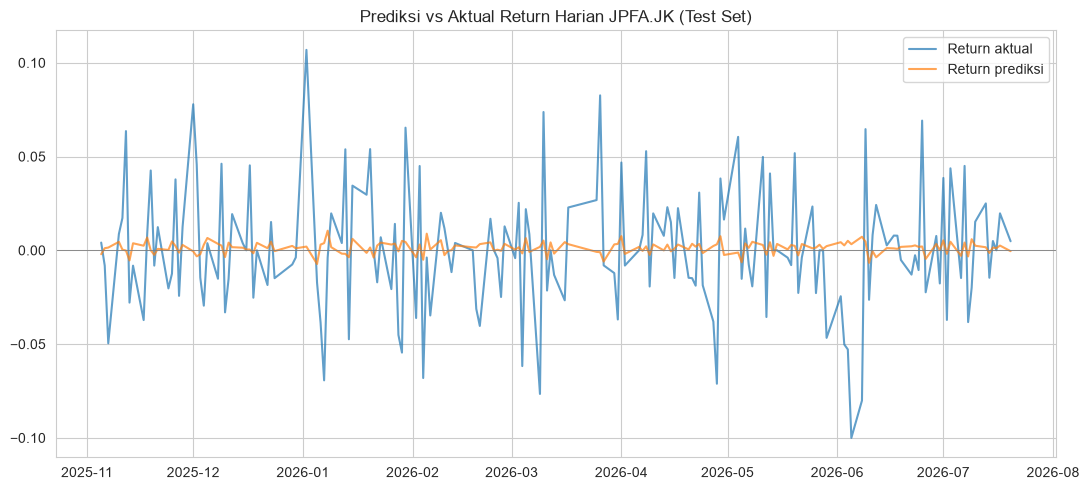

In [8]:
TICKER_TARGET = "JPFA.JK"
N_LAG = 5

df_model = pd.DataFrame({"return": returns[TICKER_TARGET]}).dropna()
for lag in range(1, N_LAG + 1):
    df_model[f"lag_{lag}"] = df_model["return"].shift(lag)
df_model = df_model.dropna()

# Split berbasis waktu (bukan acak) - wajib untuk data time series
split_idx = int(len(df_model) * 0.8)
train, test = df_model.iloc[:split_idx], df_model.iloc[split_idx:]

fitur = [f"lag_{i}" for i in range(1, N_LAG + 1)]
X_train, y_train = train[fitur], train["return"]
X_test, y_test = test[fitur], test["return"]

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"Model: prediksi return harian {TICKER_TARGET} dari {N_LAG} hari sebelumnya")
print(f"R² (test set)  : {r2:.4f}")
print(f"RMSE (test set): {rmse:.4f}")

plt.figure(figsize=(11, 5))
plt.plot(test.index, y_test, label="Return aktual", alpha=0.7)
plt.plot(test.index, pred, label="Return prediksi", alpha=0.7)
plt.axhline(0, color="gray", linewidth=0.6)
plt.title(f"Prediksi vs Aktual Return Harian {TICKER_TARGET} (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Chart Tambahan untuk Slide Deck

Dua chart berikut disimpan sebagai file PNG (background putih, resolusi tinggi/300 dpi) untuk dipakai
langsung di slide deck: (1) excess return tiap emiten dibanding IHSG pada Periode 2, dan (2) Sharpe
Ratio ketujuh ticker, diurutkan dari tertinggi ke terendah.

In [9]:
import matplotlib.font_manager as fm

# Design tokens dari Figma - dipakai konsisten di 3 chart slide deck
# (chart_return_kumulatif.png, chart_excess_return_periode2.png, chart_sharpe_ratio.png)
POSITIF = "#276B45"
NEGATIF = "#B23A32"
TEKS_SEKUNDER = "#7C726C"
TEKS_UTAMA = "#1A1614"
BG = "#FFFFFF"
GRID = "#E7E0DB"

FONT_SANS = "Arial"
_mono_tersedia = any("plex mono" in f.name.lower() for f in fm.fontManager.ttflist)
FONT_MONO = "IBM Plex Mono" if _mono_tersedia else "DejaVu Sans Mono"


def fmt_id(v):
    """Format Indonesia: koma sbg desimal, tanda +/- eksplisit."""
    tanda = "+" if v > 0 else ("-" if v < 0 else "")
    return f"{tanda}{abs(v):.2f}".replace(".", ",") + "%"

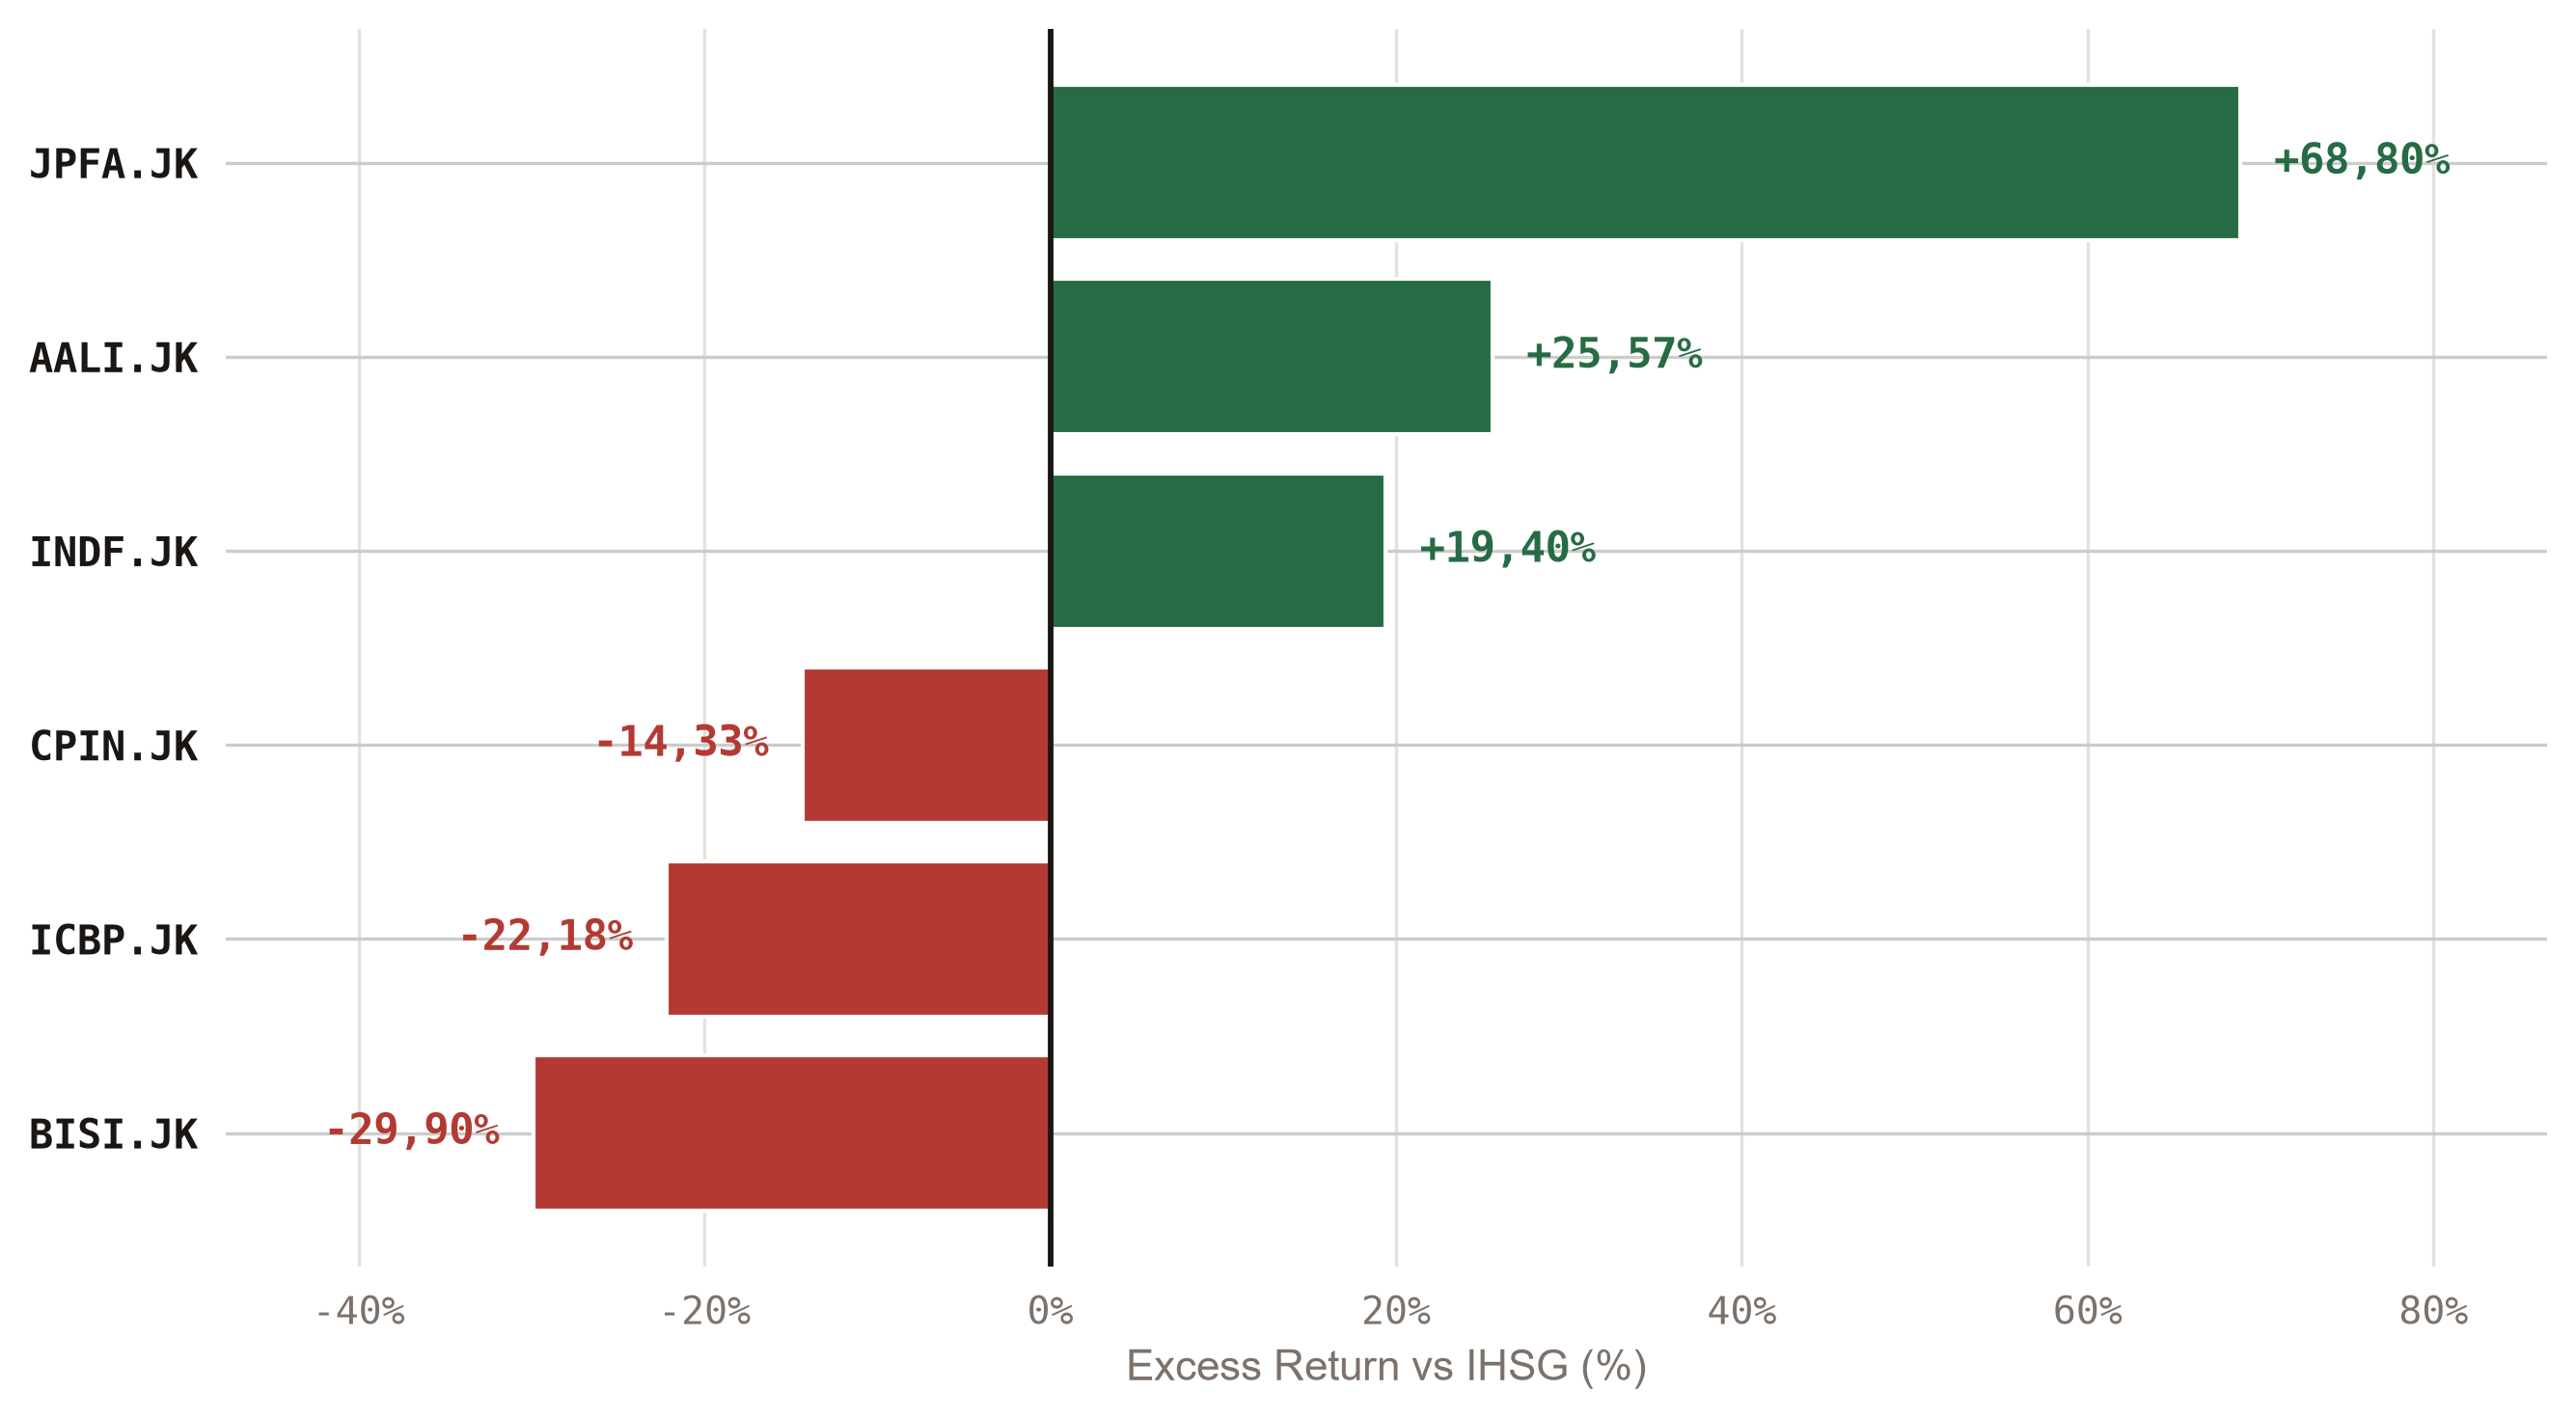

Price
BISI.JK   -29.90
ICBP.JK   -22.18
CPIN.JK   -14.33
INDF.JK    19.40
AALI.JK    25.57
JPFA.JK    68.80
Name: return_kumulatif(%), dtype: float64

In [10]:
p2 = ringkasan[ringkasan["periode"].str.contains("Periode 2")].set_index("Price")
ihsg_return_p2 = p2.loc["^JKSE", "return_kumulatif(%)"]
emiten_p2 = p2.drop(index="^JKSE")

excess_return_p2 = (emiten_p2["return_kumulatif(%)"] - ihsg_return_p2).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

warna = [POSITIF if x > 0 else NEGATIF for x in excess_return_p2]
bars = ax.barh(excess_return_p2.index, excess_return_p2.values, color=warna, zorder=3)
ax.margins(x=0.18)  # beri ruang ekstra biar label nilai di ujung bar tidak tabrakan dgn tick label

for bar, v, w in zip(bars, excess_return_p2.values, warna):
    offset = (excess_return_p2.max() - excess_return_p2.min()) * 0.02
    x_lbl = v + offset if v > 0 else v - offset
    ha = "left" if v > 0 else "right"
    ax.text(x_lbl, bar.get_y() + bar.get_height() / 2, fmt_id(v), ha=ha, va="center",
            fontsize=10.5, color=w, fontfamily=FONT_MONO, fontweight="bold")

ax.axvline(0, color=TEKS_UTAMA, linewidth=1.4, zorder=4)
ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

ax.set_xlabel("Excess Return vs IHSG (%)", color=TEKS_SEKUNDER, fontsize=10.5, fontfamily=FONT_SANS)
ax.xaxis.set_major_formatter(lambda x, _: f"{int(x)}%")
ax.tick_params(axis="x", colors=TEKS_SEKUNDER, labelsize=9.5)
for lbl in ax.get_xticklabels():
    lbl.set_fontfamily(FONT_MONO)
for lbl in ax.get_yticklabels():
    lbl.set_fontfamily(FONT_MONO)
    lbl.set_color(TEKS_UTAMA)
    lbl.set_fontweight("bold")

plt.tight_layout()
plt.savefig("chart_excess_return_periode2.png", dpi=300, facecolor=BG)
plt.show()

excess_return_p2.round(2)

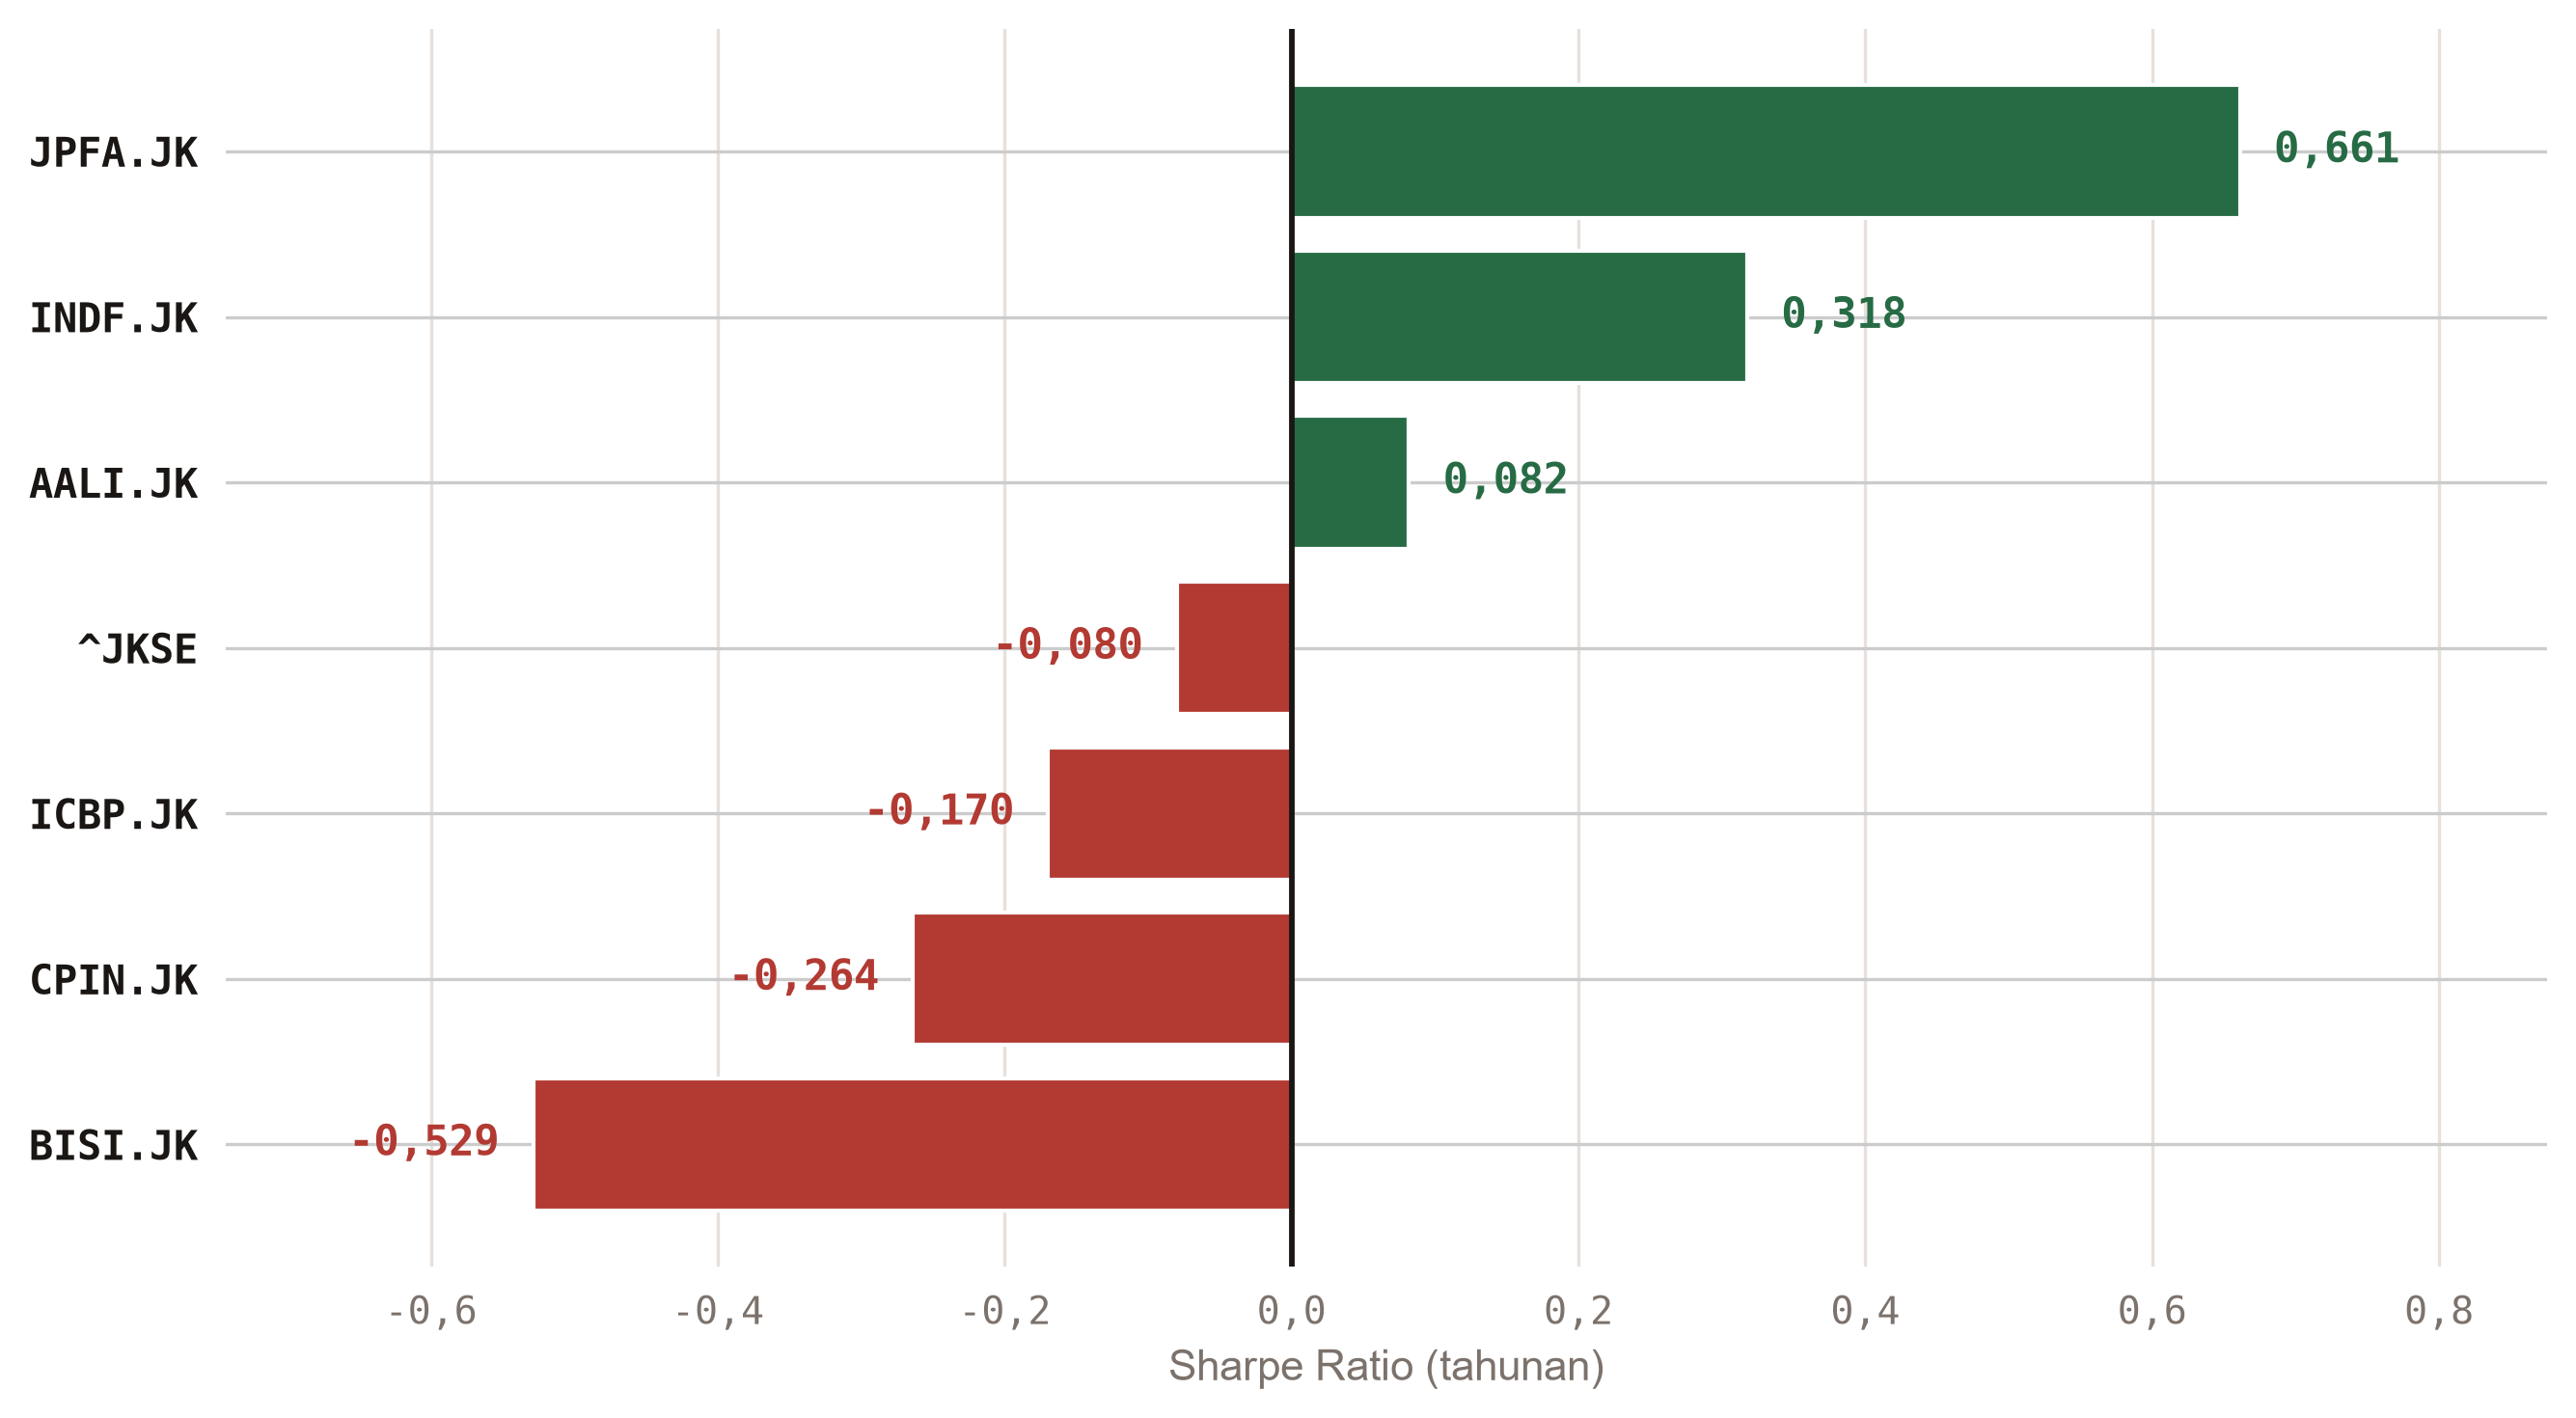

JPFA.JK    0.661
INDF.JK    0.318
AALI.JK    0.082
^JKSE     -0.080
ICBP.JK   -0.170
CPIN.JK   -0.264
BISI.JK   -0.529
Name: Sharpe Ratio (tahunan), dtype: float64

In [11]:
df_sharpe_plot = df_sharpe.sort_values(ascending=True)  # ascending agar barh menampilkan tertinggi di atas

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

warna = [POSITIF if x > 0 else NEGATIF for x in df_sharpe_plot]
bars = ax.barh(df_sharpe_plot.index, df_sharpe_plot.values, color=warna, zorder=3)
ax.margins(x=0.18)  # beri ruang ekstra biar label nilai di ujung bar tidak tabrakan dgn tick label

for bar, v, w in zip(bars, df_sharpe_plot.values, warna):
    offset = (df_sharpe_plot.max() - df_sharpe_plot.min()) * 0.02
    x_lbl = v + offset if v > 0 else v - offset
    ha = "left" if v > 0 else "right"
    label = f"{v:.3f}".replace(".", ",")
    ax.text(x_lbl, bar.get_y() + bar.get_height() / 2, label, ha=ha, va="center",
            fontsize=10.5, color=w, fontfamily=FONT_MONO, fontweight="bold")

ax.axvline(0, color=TEKS_UTAMA, linewidth=1.4, zorder=4)
ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

ax.set_xlabel("Sharpe Ratio (tahunan)", color=TEKS_SEKUNDER, fontsize=10.5, fontfamily=FONT_SANS)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1f}".replace(".", ","))
ax.tick_params(axis="x", colors=TEKS_SEKUNDER, labelsize=9.5)
for lbl in ax.get_xticklabels():
    lbl.set_fontfamily(FONT_MONO)
for lbl in ax.get_yticklabels():
    lbl.set_fontfamily(FONT_MONO)
    lbl.set_color(TEKS_UTAMA)
    lbl.set_fontweight("bold")

plt.tight_layout()
plt.savefig("chart_sharpe_ratio.png", dpi=300, facecolor=BG)
plt.show()

df_sharpe.round(3)

## 7. Kesimpulan

Empat metrik tambahan ini memberi gambaran yang lebih lengkap: (1) JPFA.JK tetap jadi satu-satunya saham dengan Sharpe Ratio positif signifikan (0,661), menegaskan performanya bukan cuma soal return tinggi tapi juga return yang sepadan dengan risikonya; (2) dari sisi risiko murni, BISI.JK punya Max Drawdown terdalam (-66,72%), sementara INDF.JK justru paling tahan banting, bahkan lebih stabil dari IHSG; (3) meski demikian, uji-t menunjukkan tidak ada satu pun perbedaan return antar periode yang signifikan secara statistik (p-value semua > 0,05) — jadi pola ‘sebelum vs sesudah’ yang terlihat di dashboard perlu dibaca sebagai indikasi deskriptif, bukan bukti pergeseran struktural yang pasti; (4) model forecasting dengan R² sangat rendah (0,017) mengonfirmasi bahwa return harian saham-saham ini praktis tidak bisa diprediksi dari pola harga masa lalunya sendiri, sejalan dengan teori pasar efisien.

> Seluruh analisis di notebook ini dibuat untuk tujuan pembelajaran dan portofolio data analyst/data
> scientist, bukan merupakan rekomendasi atau nasihat investasi.